# 점과 직선 사이의 거리

직선 $ax + by + c = 0$과 점 $(x_0, y_0)$ 사이의 거리:

$$
d = \frac{\lvert ax_0 + by_0 + c \rvert}{\sqrt{a^2 + b^2}}
$$


## 1. 공식 구현


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def point_line_distance(x0, y0, a, b, c):
    """점 (x0,y0)와 직선 ax+by+c=0 사이 거리"""
    return np.abs(a*x0 + b*y0 + c) / np.sqrt(a**2 + b**2)

# 예: 점 (1, 2), 직선 3x - 4y + 5 = 0
x0, y0 = 1, 2
a, b, c = 3, -4, 5
d = point_line_distance(x0, y0, a, b, c)
print(f"점 ({x0}, {y0}), 직선 {a}x + ({b})y + {c} = 0")
print(f"거리 d = {d}")
print(f"검산: |3·1 + (-4)·2 + 5| / 5 = {abs(3*1 - 4*2 + 5)/5}")


점 (1, 2), 직선 3x + (-4)y + 5 = 0
거리 d = 0.0
검산: |3·1 + (-4)·2 + 5| / 5 = 0.0


**np.abs / np.sqrt**: <br>
=> 절댓값 · 제곱근

분모 $\sqrt{a^2+b^2}$는 법선 벡터 $(a,b)$의 크기.


## 2. 여러 점 예제


In [2]:
# 같은 직선에 대해 여러 점
points = [(0, 0), (1, 2), (-1, 1), (3, 4)]
print(f"직선: {a}x + ({b})y + {c} = 0")
for p in points:
    dist = point_line_distance(p[0], p[1], a, b, c)
    print(f"  점 {p} → d = {dist:.4f}")


직선: 3x + (-4)y + 5 = 0
  점 (0, 0) → d = 1.0000
  점 (1, 2) → d = 0.0000
  점 (-1, 1) → d = 0.4000
  점 (3, 4) → d = 0.4000


## 3. 간단한 시각화

수선의 발: 점에서 직선으로의 법선 방향 투영.


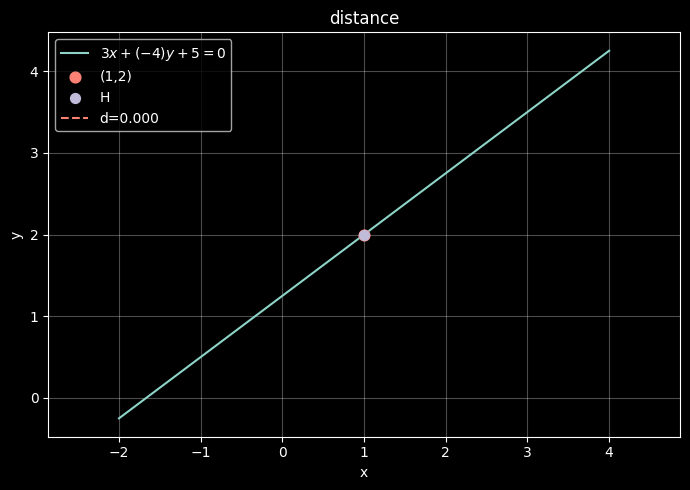

In [5]:
# 직선 그리기: 3x - 4y + 5 = 0 → y = (3x+5)/4
xs = np.linspace(-2, 4, 200)
ys_line = (a*xs + c) / (-b)  # b=-4 → y=(3x+5)/4

# 수선의 발 H: H = P - t*(a,b), t = (ax0+by0+c)/(a^2+b^2)
t = (a*x0 + b*y0 + c) / (a**2 + b**2)
H = np.array([x0 - t*a, y0 - t*b])

plt.figure(figsize=(7, 5))
plt.plot(xs, ys_line, label=rf'${a}x+({b})y+{c}=0$', color='C0')
plt.scatter([x0], [y0], color='C3', s=60, zorder=5, label=f'({x0},{y0})')
plt.scatter([H[0]], [H[1]], color='C2', s=50, zorder=5, label='H')
plt.plot([x0, H[0]], [y0, H[1]], 'C3--', lw=1.5, label=f'd={d:.3f}')
plt.gca().set_aspect('equal', adjustable='datalim')
plt.xlabel('x'); plt.ylabel('y')
plt.title('distance')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
